In [1]:
import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
import pandas as pd
import matplotlib.pyplot as plt

from inception.instruments.constant_parameters import NOTES_PARAMETERS

SPDR® Dow Jones® Industrial Average ETF Trust (Bloomberg ticker: DIA) (the “DIA”), the SPDR® S&P 500® ETF Trust (Bloomberg ticker: SPY) (the “SPY”), and the Health Care Select Sector SPDR® Fund (Bloomberg ticker: XLV) (the “XLV”) (each, a “Fund” and together, the “Funds”)

In [2]:
from pandas_datareader import data as pdr

import yfinance as yf
yf.pdr_override() # <== that's all it takes :-)

# download dataframe
data_dia = pdr.get_data_yahoo("DIA", start="2014-01-01", end="2024-03-01")
data_spy = pdr.get_data_yahoo("SPY", start="2014-01-01", end="2024-03-01")
data_xlv = pdr.get_data_yahoo("XLV", start="2014-01-01", end="2024-03-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
log_return = np.c_[np.diff(np.log(data_dia.Close)), np.diff(np.log(data_spy.Close)), np.diff(np.log(data_xlv.Close))]
log_df = pd.DataFrame(log_return)
log_df['label'] = [i // 22 for i in log_df.index]
corr_matrix = np.corrcoef(log_df.groupby('label').sum().T)

In [4]:
corr_matrix 

array([[1.        , 0.96432854, 0.80799003],
       [0.96432854, 1.        , 0.8267037 ],
       [0.80799003, 0.8267037 , 1.        ]])

In [5]:
calc_dates = ['2024-06-13', '2024-07-13', '2024-08-13', '2024-09-13', '2024-10-13', '2024-11-13',
              '2024-12-13', '2025-01-13', '2025-02-13', '2025-03-13', '2025-04-13', '2025-05-13',
              '2025-06-13', '2025-07-13', '2025-08-13', '2025-09-13', '2025-10-13', '2025-11-13',
              '2025-12-13', '2026-01-13', '2026-02-16', '2026-03-13', '2026-04-13', '2026-05-13',
              '2026-06-13', '2026-07-13', '2026-08-13', '2026-09-13', '2026-10-13', '2026-11-15',
              '2026-12-13', '2027-01-13', '2027-02-15', '2027-03-13', '2027-04-13', '2027-05-13',
              '2027-06-13', '2027-07-13', '2027-08-15', '2027-09-13', '2027-10-13', '2027-11-14',
              '2027-12-13', '2028-01-13', '2028-02-13']

In [7]:
eval_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
spot_price = np.array([382.82, 494.08, 142.86])

index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']

price_percentage = np.arange(0.6, 1.2, 0.025)
values = []
for i, p in enumerate(price_percentage):
    values.append([])
    for d in calc_dates:
        simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price * p, risk_free_rate, index_vol, corr_matrix, d_s)
        notes = MultiAssetAutoCallableNote(d,
                                           simulator, 
                                           parameters['valuation dates'],
                                           parameters['coupon dates'],
                                           parameters['call dates'],
                                           coupon_barrier=parameters['coupon barrier'],
                                           call_barrier=parameters['call barrier'],
                                           principal_barrier=parameters['principal barrier'],
                                           coupon_amount=parameters['coupon amount'],
                                           free_rate=risk_free_rate,
                                           n_paths=path_num)
        values[i].append(notes.value)



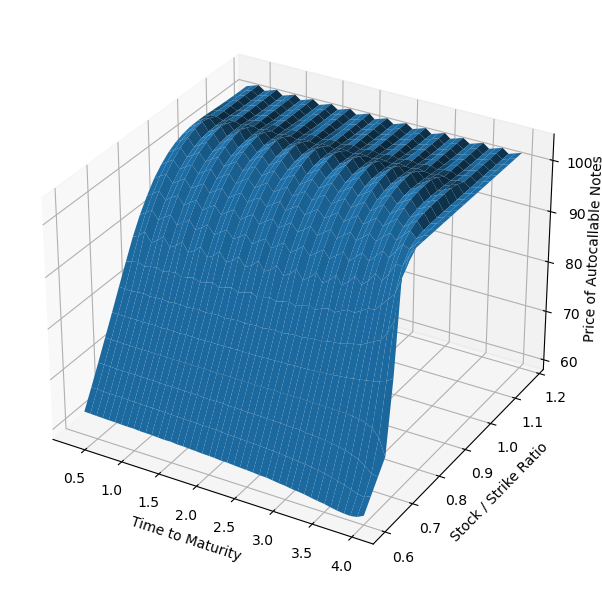

In [8]:
fig = plt.figure(figsize =(6, 6))
ax = plt.axes(projection ='3d')

dates = [pd.Timestamp(d) for d in calc_dates]
times = [(d - pd.Timestamp(eval_date)).total_seconds() / 3600 / 24 / 365 for d in dates]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values))

ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7
plt.tight_layout()

In [9]:
calc_dates = [
            '2023-10-10', '2023-11-12', '2023-12-10', '2024-01-09', '2024-02-10', '2024-03-10',
            '2024-04-10', '2024-05-12', '2024-06-10', '2024-07-10', '2024-08-11', '2024-09-10',
            '2024-10-09', '2024-11-10', '2024-12-10', '2025-01-12', '2025-02-09', '2025-03-10',
            '2025-04-08', '2025-05-11', '2025-06-10', '2025-07-10', '2025-08-10', '2025-09-10',
            '2025-10-09', '2025-11-10', '2025-12-10', '2026-01-11', '2026-02-09', '2026-03-10',
            '2026-04-12', '2026-05-10', '2026-06-10', '2026-07-12', '2026-08-10', '2026-09-10',
            '2026-10-08', '2026-11-10', '2026-12-10', '2027-01-10', '2027-02-09', '2027-03-10',
            '2027-04-11', '2027-05-10', '2027-06-10', '2027-07-11', '2027-08-10', '2027-09-12',
            '2027-10-07', '2027-11-10', '2027-12-12', '2028-01-09', '2028-02-10', '2028-03-12',
            '2028-04-09', '2028-05-10', '2028-06-11', '2028-07-10', '2028-08-10', '2028-09-10',
            '2028-10-10', '2028-11-12', '2028-12-10', '2029-01-09', '2029-02-11', '2029-03-11',
            '2029-04-10', '2029-05-10', '2029-06-10', '2029-07-10', '2029-08-12', '2029-09-10',
            '2029-10-10', '2029-11-11', '2029-12-10', '2030-01-10', '2030-02-10', '2030-03-10',
            '2030-04-10', '2030-05-12', '2030-06-10', '2030-07-10', '2030-08-11', '2030-09-10'
]

In [13]:
from inception.instruments import ReferenceIndexReturnSimulator, AutoCallableNote

In [11]:
import time
eval_date = '2023-09-18'
issued_price = 775
spot_price = 775

index_vol = 0.3
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC']

t1 = time.time()
simulator = ReferenceIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, delta_s=d_s)
notes = AutoCallableNote(eval_date,
                         simulator, 
                         parameters['valuation dates'],
                         parameters['coupon dates'],
                         parameters['call dates'],
                         coupon_barrier=parameters['coupon barrier'],
                         call_barrier=parameters['call barrier'],
                         principal_barrier=parameters['principal barrier'],
                         coupon_amount=parameters['coupon amount'],
                         free_rate=risk_free_rate,
                         n_paths=path_num)

print(f'The value of Auto-Callable Notes: {notes.value:.2f}')
# print(f'The delta of Auto-Callable Notes: {notes.delta:.2f}')
# print(f'The gamma of Auto-Callable Notes: {notes.gamma:.2f}')
# print(f'The rho of Auto-Callable Notes: {notes.rho:.2f}')

print(time.time() - t1)

The value of Auto-Callable Notes: 100.08
3.4674875736236572


In [12]:
issued_price = 775
spot_price = 775

index_vol = 0.3
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC']

price_percentage = np.arange(0.6, 1.2, 0.025)
values = []
for i, p in enumerate(price_percentage):
    values.append([])
    for d in calc_dates:
        simulator = ReferenceIndexReturnSimulator(issued_price, spot_price * p, risk_free_rate, index_vol, delta_s=d_s)
        notes = AutoCallableNote(d,
                                 simulator, 
                                 parameters['valuation dates'],
                                 parameters['coupon dates'],
                                 parameters['call dates'],
                                 coupon_barrier=parameters['coupon barrier'],
                                 call_barrier=parameters['call barrier'],
                                 principal_barrier=parameters['principal barrier'],
                                 coupon_amount=parameters['coupon amount'],
                                 free_rate=risk_free_rate,
                                 n_paths=path_num)
        values[i].append(notes.value)


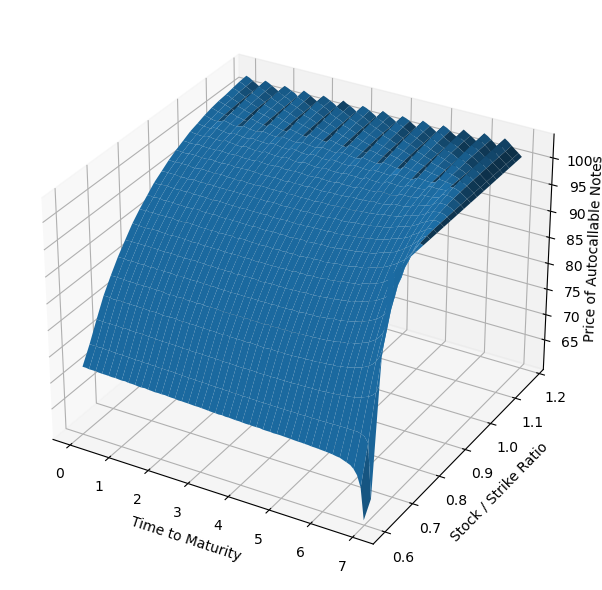

In [13]:
fig = plt.figure(figsize =(6, 6))
ax = plt.axes(projection ='3d')
eval_date = '2023-09-18'
dates = [pd.Timestamp(d) for d in calc_dates]
times = [(d - pd.Timestamp(eval_date)).total_seconds() / 3600 / 24 / 365 for d in dates]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values))

ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7
plt.tight_layout()

In [14]:
date_range = pd.bdate_range('2023-08-18', '2025-09-10')

In [ ]:
issued_price = 775
spot_price = 775

index_vol = 0.3
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC']
date_range = pd.bdate_range('2023-08-18', '2025-09-10')
dates = [d for i, d in enumerate(date_range) if i % 3 == 0]
price_percentage = np.arange(0.7, 0.9, 0.02)
values = []
for i, p in enumerate(price_percentage):
    values.append([])
    for d in dates:
        simulator = ReferenceIndexReturnSimulator(issued_price, spot_price * p, risk_free_rate, index_vol, delta_s=d_s)
        notes = AutoCallableNote(d,
                                 simulator, 
                                 parameters['valuation dates'],
                                 parameters['coupon dates'],
                                 parameters['call dates'],
                                 coupon_barrier=parameters['coupon barrier'],
                                 call_barrier=parameters['call barrier'],
                                 principal_barrier=parameters['principal barrier'],
                                 coupon_amount=parameters['coupon amount'],
                                 free_rate=risk_free_rate,
                                 n_paths=path_num)
        values[i].append(notes.value)


In [ ]:
fig = plt.figure(figsize =(6, 6))
ax = plt.axes(projection ='3d')
eval_date = '2023-09-18'
times = [(d - pd.Timestamp(eval_date)).total_seconds() / 3600 / 24 / 365 for d in dates]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values))

ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7
plt.tight_layout()

In [14]:
issued_price = 775
spot_price = 775

index_vol = 0.3
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC']

date_range = pd.bdate_range('2023-08-18', '2030-09-10')

d_values = []
for d in date_range:
    simulator = ReferenceIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, delta_s=d_s)
    notes = AutoCallableNote(d,
                             simulator, 
                             parameters['valuation dates'],
                             parameters['coupon dates'],
                             parameters['call dates'],
                             coupon_barrier=parameters['coupon barrier'],
                             call_barrier=parameters['call barrier'],
                             principal_barrier=parameters['principal barrier'],
                             coupon_amount=parameters['coupon amount'],
                             free_rate=risk_free_rate,
                             n_paths=path_num)
    d_values.append(notes.value)

Text(0.5, 1.0, 'Monthly Coupon, Semi-Annual Call')

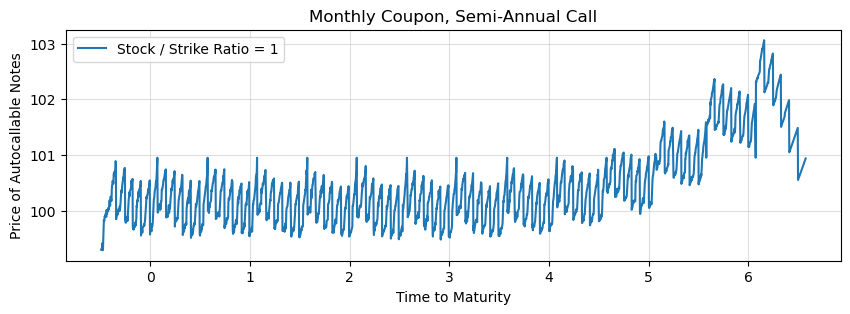

In [16]:
plt.figure(figsize=(10, 3))
times = [(d - pd.Timestamp(eval_date)).total_seconds() / 3600 / 24 / 365 for d in date_range]
plt.plot(times, d_values, label='Stock / Strike Ratio = 1')
plt.grid(alpha=0.4)
plt.xlabel('Time to Maturity')
plt.ylabel('Price of Autocallable Notes')
plt.legend()
plt.title('Monthly Coupon, Semi-Annual Call')

In [ ]:
issued_price = 775
spot_price = 775

index_vol = 0.3
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC']

date_range = pd.bdate_range('2023-08-18', '2030-09-10')

d_values = []
for d in date_range:
    simulator = ReferenceIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, delta_s=d_s)
    notes = AutoCallableNote(d,
                             simulator, 
                             parameters['valuation dates'],
                             parameters['coupon dates'],
                             parameters['call dates'],
                             coupon_barrier=parameters['coupon barrier'],
                             call_barrier=parameters['call barrier'],
                             principal_barrier=parameters['principal barrier'],
                             coupon_amount=parameters['coupon amount'],
                             free_rate=risk_free_rate,
                             n_paths=path_num)
    d_values.append(notes.value)

In [6]:
eval_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
spot_price = np.array([382.82, 494.08, 142.86])

index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
path_num = 100_000
d_s = 0.02
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
date_range = pd.bdate_range('2024-02-14', '2028-02-13')
d_values = []
for d in date_range:
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(d,
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)
    d_values.append(notes.value)


Text(0.5, 1.0, 'Quarterly Coupon, Quarterly Call')

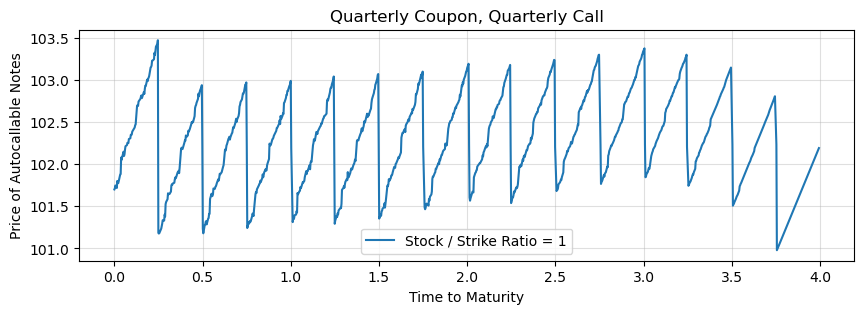

In [11]:
plt.figure(figsize=(10, 3))
times = [(d - pd.Timestamp(eval_date)).total_seconds() / 3600 / 24 / 365 for d in date_range]
plt.plot(times, d_values, label='Stock / Strike Ratio = 1')
plt.grid(alpha=0.4)
plt.xlabel('Time to Maturity')
plt.ylabel('Price of Autocallable Notes')
plt.legend()
plt.title('Quarterly Coupon, Quarterly Call')